# The Second Part of the Assignment of IDS 2019-2020
Document your results as well as the way you obtained them in this jupyter notebook. Separate reports (pdf, word, etc.) are _not_ required. However, it is necessary that you provide the python code leading to your results as well as textual answers to the assignment questions in this notebook. *DO NOT CLEAR THE OUTPUT of the notebook you are submitting!* In the cases that the result of an algorithm is pdf, jpg, etc, you should attach the result to this notebook file and refer to that in the text.  

Next to the jupyter notebook, submit one zip-file containing all data sets that you are asked to submit. Make sure they are easily identifiable, i.e. use names as requested in the corresponding question.

Do not change the general structure of this notebook, but you can add further markdown or code cells to explain your solutions if necessary. In the end, submit this file and your created data sets in moodle.

Only <font color="red">one </font> group member should upload your group's solution.*Make sure to include group members' names and matriculation numbers*. If your name and student id are not included in the report, you will not receive any points!


Hint 1: While answering the questions, you will get a better and better impression of the given data. <font color="red"><b>Ensure that all claims you make are supported by the presented facts!</b></font>

Hint 2: <font color="red"><b>Some of the tasks might need some time to run. Take this into account in your planning.</b></font>

Hint 3: RWTHonline allows for multiple submissions (each submission overwrites the previous ones). <font color="red"><b>Partial submissions are possible and encouraged. </b></font> This helps in case of technical problems of RWTHonline, which do seldomly happen.

<font color="red"><b>Student Names and IDs:
    1. Niklas Gruhn (389343)
    2. Yat Wai Wong (391265)
    3. Anisa Kusumadewi (402433)

## Preprocessing of the Dataset (5 points)

The provided data set *air_pollution* contains hourly results of measuring the concentration of certain substances (CO, Benzene, NO2, particulate matter) and environmental conditions (temperature, relative humidity, traffic volume). This data was collected near a busy street in a city center by an automated device.

 You should carry out some preprocessing steps before starting the analysis:
 - Select 90% of 'air_pollution' dataset by random sampling. Use one of the group member's student number as a seed.
 - After completing this preprocessing step, export your final dataset as 'air_pollution_2.csv' dataset and use that for the next steps of the assignment.
 - If it is not directly mentioned, you should always use your extracted (above-created) dataset.
 - <font color='red'>Important!</font> Make sure that you submit your extracted dataset with your result in moodle.

In [6]:
import pandas as pd

dataset_q0 = pd.read_csv("air_pollution.csv")
dataset_q0 = dataset_q0.sample(frac=0.9, random_state=389343)
dataset_q0.to_csv("air_pollution_2.csv", index=False)
dataset_q0

,Date,Time,CO,Benzene,NO2,Temperature,Humidity(%),Traffic_Volume,Particulate_Matter
6836,20.12.04,17:00:00,2.9,6.8,129,8.9,44.9,NaN,NaN
704,09.04.04,16:00:00,3.6,-200.0,139,-200.0,-200.0,136.803162,154.095077
6975,26.12.04,9:00:00,0.9,2.5,117,10.4,82.9,NaN,NaN
2252,12.06.04,15:00:00,1.2,8.6,76,37.0,20.1,NaN,NaN
9289,01.04.05,10:00:00,1.0,3.5,120,16.5,40.8,NaN,NaN
...,...,...,...,...,...,...,...,...,...
8137,12.02.05,23:00:00,4.5,20.4,231,10.1,59.9,NaN,NaN
1691,20.05.04,6:00:00,0.9,6.6,68,15.8,59.0,126.221154,69.275184
9174,28.03.05,6:00:00,0.6,1.9,63,13.9,78.0,NaN,NaN
1203,29.04.04,7:00:00,4.9,29.8,95,14.8,61.3,36.793635,144.350250


## Question 1 - Data Preprocessing and Data Quality (10 points)

For this question, use the extracted data set you created in the preprocessing step ('air_pollution_2.csv'), but without the features *Traffic_Volume* and *Particulate_Matter*. Remove those columns before answering the questions.

In [7]:
import pandas as pd

dataset_q1a = pd.read_csv("air_pollution_2.csv")
dataset_q1a = dataset_q1a.iloc[:,:-2]

dataset_q1a

,Date,Time,CO,Benzene,NO2,Temperature,Humidity(%)
0,20.12.04,17:00:00,2.9,6.8,129,8.9,44.9
1,09.04.04,16:00:00,3.6,-200.0,139,-200.0,-200.0
2,26.12.04,9:00:00,0.9,2.5,117,10.4,82.9
3,12.06.04,15:00:00,1.2,8.6,76,37.0,20.1
4,01.04.05,10:00:00,1.0,3.5,120,16.5,40.8
...,...,...,...,...,...,...,...
8416,12.02.05,23:00:00,4.5,20.4,231,10.1,59.9
8417,20.05.04,6:00:00,0.9,6.6,68,15.8,59.0
8418,28.03.05,6:00:00,0.6,1.9,63,13.9,78.0
8419,29.04.04,7:00:00,4.9,29.8,95,14.8,61.3


(a) We want to get a first impression of the data. To achieve this, compute and show the following:
    - the column names (names of the features)
    - the data type of each feature
    - for categorical features: the number of classes and the value of the most frequent class
    - for numerical features: the mean, standard deviation, minimum and maximum


#### Features And Data Types

In [8]:
dataset_q1a.dtypes

Date            object
Time            object
CO             float64
Benzene        float64
NO2              int64
Temperature    float64
Humidity(%)    float64
dtype: object

#### Properties of Numerical Features

In [9]:
numerical_features = dataset_q1a.loc[:,["CO", "Benzene", "NO2", "Temperature", "Humidity(%)"]]
numerical_features.describe().loc[["mean", "std", "min", "max"]]

,CO,Benzene,NO2,Temperature,Humidity(%)
mean,-34.052559,1.717254,57.951075,9.657345,39.389039
std,77.522196,41.635255,126.976177,43.481943,51.532352
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
max,11.900000,63.700000,340.000000,44.600000,88.700000


#### Properties of Categorical Features

In [10]:
categorical_features = dataset_q1a.loc[:,["Date", "Time"]]
categorical_features.describe().loc[["count", "top"]]

,Date,Time
count,8421,8421
top,18.10.04,12:00:00


(b) Consider the features 'date' and 'time'. Combine them into a new column 'Datetime' using the datetime data type, and drop the old columns 'date' and 'time'. 

Which of the two representations of date and time do you think is more suitable for most analysis applications?

Explanation:

Separate features for date and time are useful when we expect them to be independent for the patterns we are interested in. A trivial example would be daylight intensity which depends stongly on time but less on the date. Presuming that for most applications, target features are not date independent, a combined date-time feature is more suitable. 

In [11]:
dataset_q1b = dataset_q1a
dataset_q1b["Datetime"] = pd.to_datetime(dataset_q1b["Date"] + " " + dataset_q1b["Time"])
dataset_q1b = dataset_q1b.iloc[:,2:]
dataset_q1b.info()

dataset_q1b.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8421 entries, 0 to 8420
Data columns (total 6 columns):
CO             8421 non-null float64
Benzene        8421 non-null float64
NO2            8421 non-null int64
Temperature    8421 non-null float64
Humidity(%)    8421 non-null float64
Datetime       8421 non-null datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 394.9 KB


,CO,Benzene,NO2,Temperature,Humidity(%)
count,8421.000000,8421.000000,8421.000000,8421.000000,8421.000000
mean,-34.052559,1.717254,57.951075,9.657345,39.389039
std,77.522196,41.635255,126.976177,43.481943,51.532352
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,4.000000,53.000000,10.900000,34.100000
50%,1.500000,7.900000,96.000000,17.200000,48.500000
75%,2.600000,13.600000,133.000000,24.000000,62.000000
max,11.900000,63.700000,340.000000,44.600000,88.700000


(c) For each feature corresponding to a measured value, provide a simple scatter plot showing the data points over time. Can you spot any obvious data quality issues, e.g. inconsistencies, implausible values or missing values (without researching on specific domain knowledge)?

*Hint: you may perform additional computations to verify your findings.*

In [12]:
import matplotlib.pyplot as plt

def plot_measured_features_over_time(dataset):
    measured_features = ["CO", "Benzene", "NO2", "Temperature", "Humidity(%)"]
    
    plt.figure(figsize=(18, 12))
    plt.tight_layout()
    
    for i in range(len(measured_features)):
        plt.subplot(2, 3, i + 1)
        plt.subplots_adjust(hspace = .4)
        plt.scatter(x=dataset["Datetime"], y=dataset[measured_features[i]], s=0.3)
        plt.ylabel(measured_features[i])
        plt.xticks(rotation='vertical')
    
    plt.show()

/opt/conda/lib/python3.7/site-packages/pandas/plotting/_matplotlib/converter.py:103: FutureWarning: Using an implicitly registered datetime converter for a matplotlib plotting method. The converter was registered by pandas on import. Future versions of pandas will require you to explicitly register matplotlib converters.

To register the converters:
	>>> from pandas.plotting import register_matplotlib_converters
	>>> register_matplotlib_converters()
  warnings.warn(msg, FutureWarning)


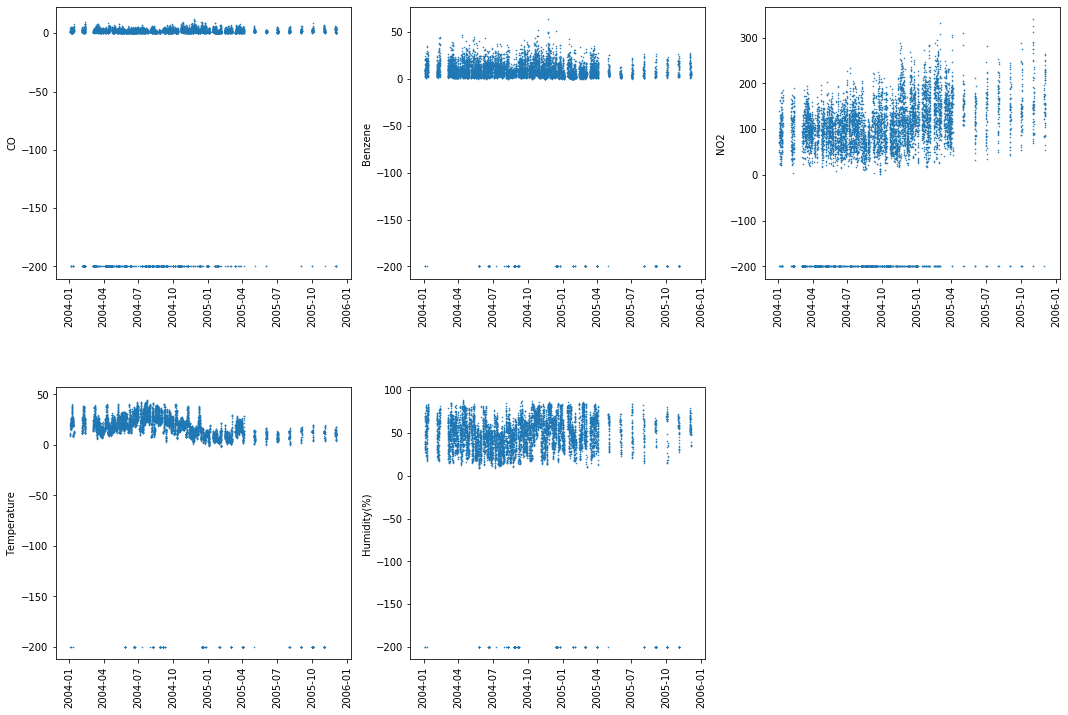

In [13]:
plot_measured_features_over_time(dataset_q1b)

Explanation:

For each measured feature there seem to be a number of data points close to the -200 mark with large margin to the remaining data points. We wouldn't expect to see this consistently for all the different features. Also, negative values don't make sense for most of the features (notice the hard cut of data points at the 0 mark for `CO` and `Benezene`). Assuming we are dealing with the celsius scale, `Temperaute` is an exception where values of -200  are technically possible but such low measurements anywhere on earth are implausible. Thus, we can assume that these values correspond to errors.

Also, beginning in April 2005 the data seems to become less dense on the x-axis for all the features. This indicates that since then measurments have either been carried out more consistensly at certain intervals or data has been aggregated.

(d) We need to handle any implausible or missing data. In the lecture, several strategies to do so have been introduced, for example, deleting data rows that contain missing/implausible values or replacing them by a value derived from other data points. 

In this question, consider implausible values to be the ones identified in question (c).

    1) For all numerical features, compute and show mean, standard deviation, minimum and maximum, while ignoring the missing and implausible values. Also, print the total number of data rows.
    
    2) Choose a strategy (or combination of strategies) to handle missing/implausible values. Create a cleaned data set with all those values handled accordingly.
    
    3) For all numerical features, compute and show mean, standard deviation, minimum and maximum with respect to your cleaned data set. Also print the total number of data rows.
    
    4) Motivate and explain your strategy and describe its (dis-)advantages compared to other options. Compare the computed statistical values before and after cleaning and briefly describe and evaluate any changes.

In [14]:
dataset_q1b.describe()

,CO,Benzene,NO2,Temperature,Humidity(%)
count,8421.000000,8421.000000,8421.000000,8421.000000,8421.000000
mean,-34.052559,1.717254,57.951075,9.657345,39.389039
std,77.522196,41.635255,126.976177,43.481943,51.532352
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,4.000000,53.000000,10.900000,34.100000
50%,1.500000,7.900000,96.000000,17.200000,48.500000
75%,2.600000,13.600000,133.000000,24.000000,62.000000
max,11.900000,63.700000,340.000000,44.600000,88.700000


In [15]:
dataset_q1d = dataset_q1b
dataset_q1d = dataset_q1d.loc[dataset_q1d["CO"] >= 0]
dataset_q1d = dataset_q1d.loc[dataset_q1d["Benzene"] >= 0]
dataset_q1d = dataset_q1d.loc[dataset_q1d["NO2"] >= 0]
dataset_q1d = dataset_q1d.loc[dataset_q1d["Temperature"] >= -100]
dataset_q1d = dataset_q1d.loc[dataset_q1d["Humidity(%)"] >= 0]

dataset_q1d.describe()

,CO,Benzene,NO2,Temperature,Humidity(%)
count,6247.000000,6247.000000,6247.000000,6247.000000,6247.000000
mean,2.176405,10.532079,113.597247,17.762078,48.921594
std,1.436059,7.446380,47.462297,8.856002,17.468772
min,0.100000,0.200000,2.000000,-1.900000,9.200000
25%,1.100000,4.900000,79.000000,11.200000,35.300000
50%,1.900000,8.800000,110.000000,16.800000,49.200000
75%,2.900000,14.500000,142.000000,23.700000,62.300000
max,11.900000,63.700000,333.000000,44.600000,88.700000


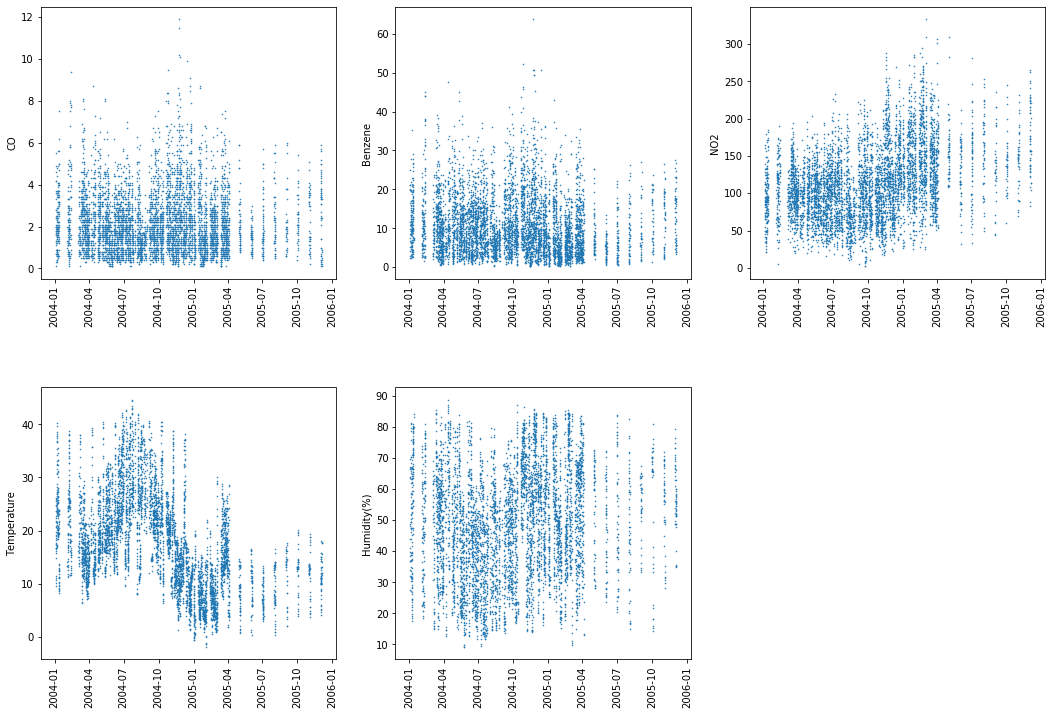

In [16]:
plot_measured_features_over_time(dataset_q1d)

Explanation: 

Justified by the explanation to part (c) we can confidently remove all negative values (except for `Temperaute`)  without introducing bias. In the case of `Temperature` we can also remove unresonably low negative values:

In [17]:
dataset_q1d["Temperature"].min()

-1.9

## Question 2 - Data Preprocessing  and Advanced Visualization (15 points)

For this question, use the extracted data set you created in the preprocessing step ('air_pollution_2.csv').

(a) To create a suitable input for the following questions, modify the data set as listed below and then print the first 5 data rows:

    - Remove the columns 'Traffic_Volume' and 'Particulate_Matter'
    - Replace the columns 'Date' and 'Time' by a combined column 'Datetime' using the datetime data type
    - Restrict the data to the timeframe between 2004-04-01 and 2005-03-31
    - Drop all rows that contain a missing value or a value below -37
    
*Hint: You may be able to reuse some of your code or data sets created above.*

In [18]:
dataset_q2a = dataset_q1d
dataset_q2a = dataset_q2a.loc[
    (dataset_q1d['Datetime'] >= '2004-04-01 00:00:00') & 
    (dataset_q1d['Datetime'] < '2005-03-31 23:59:59')
]

(b) For temperature, humidity and CO compute the mean value for each month. Create two stream graphs based on this newly computed data, that visualize the change in temperature, CO and humidity over the months:

    1) For the first stream graph, simply use the mean values you computed for each month.
    
    2) For the second stream graph, first normalize the computed mean values by mapping them individually to an interval between 0 and 1, that is, apply Min-max normalization.

In [19]:
import matplotlib.pyplot as plt

def plot_stream_graph(dataset):    
    plt.stackplot(
        dataset.index, 
        dataset['Temperature'],
        dataset['Humidity(%)'],
        dataset['CO'],
        labels=['Temperature', 'Humidity(%)', 'CO'],
        baseline='wiggle'
    )
    plt.legend(loc='upper left')
    plt.show()

In [20]:
def squash_to_month(pd_timestamp):
    return pd.Timestamp(year=pd_timestamp.year, month=pd_timestamp.month, day=1)

dataset_q2b_1 = dataset_q2a.loc[:,['Temperature', 'Humidity(%)', 'CO', 'Datetime']]
dataset_q2b_1['Year-Month'] = dataset_q2b_1['Datetime'].map(squash_to_month)
dataset_q2b_1 = dataset_q2b_1.groupby(['Year-Month']).mean()

dataset_q2b_1

,Temperature,Humidity(%),CO
Year-Month,,,
2004-04-01,18.550671,51.398658,2.503020
2004-05-01,21.885116,39.952093,1.900233
2004-06-01,25.566947,41.655368,1.997263
2004-07-01,26.673657,37.939386,1.956777
2004-08-01,26.347493,42.157522,1.611209
2004-09-01,23.738551,44.721028,2.265187
2004-10-01,21.037778,57.286420,2.467901
2004-11-01,14.411935,54.239602,2.556600
2004-12-01,13.140528,53.489688,2.438849


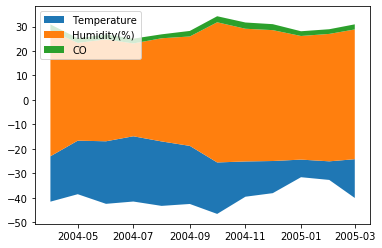

In [21]:
plot_stream_graph(dataset_q2b_1)

In [22]:
from sklearn.preprocessing import MinMaxScaler

dataset_q2b_2 = MinMaxScaler().fit_transform(dataset_q2b_1)
dataset_q2b_2 = pd.DataFrame(dataset_q2b_2, index=dataset_q2b_1.index, columns=dataset_q2b_1.columns)

dataset_q2b_2

,Temperature,Humidity(%),CO
Year-Month,,,
2004-04-01,0.582975,0.695676,0.943325
2004-05-01,0.754162,0.104032,0.305718
2004-06-01,0.943183,0.192070,0.408354
2004-07-01,1.000000,0.000000,0.365529
2004-08-01,0.983255,0.218025,0.000000
2004-09-01,0.849315,0.350526,0.691753
2004-10-01,0.710660,1.000000,0.906177
2004-11-01,0.370497,0.842518,1.000000
2004-12-01,0.305224,0.803756,0.875447


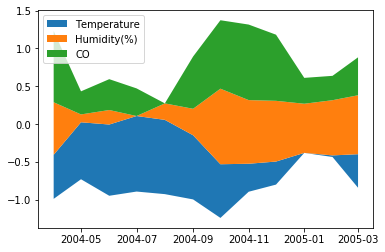

In [23]:
plot_stream_graph(dataset_q2b_2)

(c) Answer the following questions based on the stream graphs created in question 2(a) and briefly explain how you derived the answer. Which of the two stream graphs do you consider more adequate to obtain the answers?

    1) In which month is the average CO lowest?
    
    2) Is there any correlation between humidity and CO?
    
    3) Between which months is temperature increasing?

Explanation: 
    
    1) In both stream plots CO is represented by the green area. In the non-normalized plot the thickness of 
       the area appears to be nearly constant over time. This makes it hard to tell where the area is thinnest 
       and thus where the lowest value is. Normalization however, guarantees that the lowest value is mapped 
       to zero. Therefore one can easily see in the normalized stream plot that the lowest average CO is in 
       August 2004.
       
    2) From first glance, the stream plot without normalization indeed seems to suggest that there is a 
       corralation between humidity and CO since the graphs follow the same path. This is misleading though. 
       One should rather compare the change in thickness over time. Again, this is hard to determine though
       because this change is minuscule in the first plot. The second plot is better at visulazing the relative 
       change in thickness. Here we can't see any segnificant correlations.
       
    3) From May 2004 to August 2004 and Febuary 2005 to March 2005. This can be determined by looking for time 
       intervals where the thickness of the blue are is only increasing. For Temperature both graphs perform 
       reasonably well. However to answer the same question for CO again would be harder with the first graph.
       So here as well, normalization is appropriate.
       

(d) We want to create a heat map that visualizes the CO measured for different combinations of humidity and temperature. 
The heatmap should have 12 columns and 12 rows. The shown CO value should be the *median* of all values for the combination of humidity and temperature.

Modify the data as needed. Use a binning strategy of your choice for converting numerical data to categorical data. Motivate and explain all your choices and modifications.

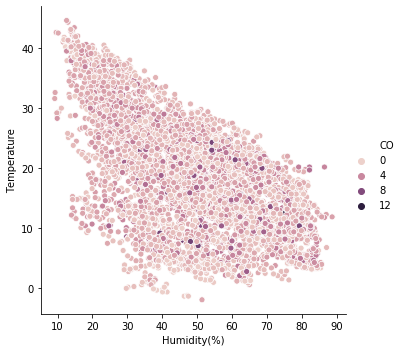

In [24]:
import seaborn as sns

sns.relplot(y="Temperature", x="Humidity(%)", hue="CO", data=dataset_q2a)

In [25]:
dataset_q2d = dataset_q2a.copy()
dataset_q2d['temperature_binned'] = pd.cut(dataset_q2d['Temperature'], bins=12)
dataset_q2d['humidity_binned'] = pd.cut(dataset_q2d['Humidity(%)'], bins=12)
dataset_q2d = dataset_q2d.pivot_table(
    index='temperature_binned', 
    columns='humidity_binned', 
    values='CO', 
    aggfunc='median'
)

dataset_q2d = dataset_q2d.sort_index(ascending=False)
dataset_q2d

humidity_binned,"(9.12, 15.825]","(15.825, 22.45]","(22.45, 29.075]","(29.075, 35.7]","(35.7, 42.325]","(42.325, 48.95]","(48.95, 55.575]","(55.575, 62.2]","(62.2, 68.825]","(68.825, 75.45]","(75.45, 82.075]","(82.075, 88.7]"
temperature_binned,,,,,,,,,,,,
"(40.725, 44.6]",1.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(36.85, 40.725]",1.4,2.00,1.60,1.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(32.975, 36.85]",2.2,1.90,2.15,1.50,1.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(29.1, 32.975]",1.6,2.00,2.10,2.50,1.60,1.70,1.70,NaN,NaN,NaN,NaN,NaN
"(25.225, 29.1]",1.4,2.20,2.10,2.10,1.90,2.20,1.50,1.50,0.9,NaN,NaN,NaN
"(21.35, 25.225]",1.3,1.20,2.30,2.00,1.70,1.60,1.60,2.15,1.8,3.80,1.50,NaN
"(17.475, 21.35]",NaN,2.10,1.35,1.80,1.90,1.95,2.20,1.90,2.0,1.85,1.60,5.10
"(13.6, 17.475]",1.6,2.00,2.50,1.75,2.10,1.50,1.65,2.10,1.6,1.75,1.40,1.80
"(9.725, 13.6]",2.6,2.55,2.05,1.50,1.30,2.40,2.05,1.50,1.6,1.45,2.30,2.65


(e) Use the modified data to create a heat map as specified in question part (c). Answer the following questions based on that heat map and briefly explain how you derived your answer:

    1) For which combination of humidity and temperature values is the median CO highest? 
    
    2) How do you explain empty fields in your heat map?
    
    3) Is CO correlating with temperature, humidity, or both?

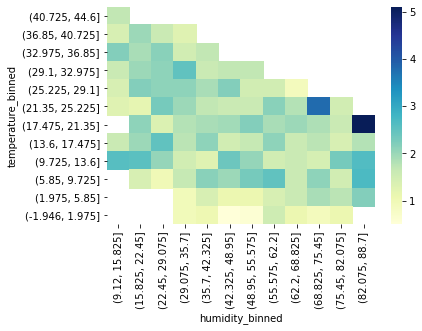

In [26]:
# Using a non-default color map. Otherwise empty fields are 
# hard to distinguish from high-median CO value fields. 
sns.heatmap(dataset_q2d, cmap="YlGnBu")

Explanation:

    1) Roughly for 19.5 degrees and 86% humidity.
    
    2) The upper-right corner of the heatmap is empty. It corresponds to both high temperature and high   
       percentage of humidity. With increasing tempature air is able to contain more water and thus more 
       water is required to reach high values of relative humidity. We know all measurements where carried 
       out in a single location only. Assuming the absolute humidity in this location does not vary 
       significantly and especially does not exceed a certain threshold, we can explain that we never observe
       high relative humidity together with high temperatures.
    
    3) Although we would at least expect to see a correlation between CO and temperature (due to the greenhouse
       effect) this is not obvious from our heatmap. To confirm our expectations we should see significantly
       more dark-colored tiles in the upper region of the plot.

## Question 3 - Clustering (15 points): 

(a) For this question, use the extracted data set you created in the preprocessing step ('air_pollution_2.csv'). Use a scatter diagram to find the relation between the 'Traffic_Volume' and 'Particulate_Matter' columns.

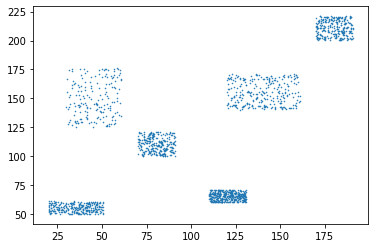

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

dataset_q2a = pd.read_csv("air_pollution_2.csv")

plt.scatter(x=dataset_q2a["Traffic_Volume"], y=dataset_q2a["Particulate_Matter"], s=0.3)
plt.show()

(b) From the previous question you found the relationship between two columns which are suitable for applying clustering methods. Find the two arrays corresponding to these to columns and drop nan values from them. Apply the k_means method for clustering the two mentioned columns. Use three different number of clusters for classifying.

In [28]:
dataset_q2b = dataset_q2a
dataset_q2b = dataset_q2b.loc[:, ["Traffic_Volume", "Particulate_Matter"]]
dataset_q2b = dataset_q2b.dropna()
dataset_q2b

,Traffic_Volume,Particulate_Matter
1,136.803162,154.095077
8,86.539477,119.305308
10,181.444859,217.756085
15,33.056678,159.407520
18,46.425166,52.975393
...,...,...
8401,128.789565,67.493874
8405,23.178809,53.082771
8417,126.221154,69.275184
8419,36.793635,144.350250


In [29]:
from sklearn.cluster import KMeans

def apply_kmeans(dataset):
    plt.figure(figsize=(18, 5))

    for k in [5, 6, 7]:
        clustering = KMeans(k)
        clustering.fit(dataset)

        labels = clustering.labels_
        centroids = clustering.cluster_centers_

        plt.subplot(1,3, k - 4)
        plt.title("k-means with k = " + str(k))
        plt.scatter(dataset["Traffic_Volume"], dataset["Particulate_Matter"], s=0.7, c=labels)
        plt.scatter(centroids[:,0], centroids[:,1], marker='x', s=50, c='red')

    plt.show()

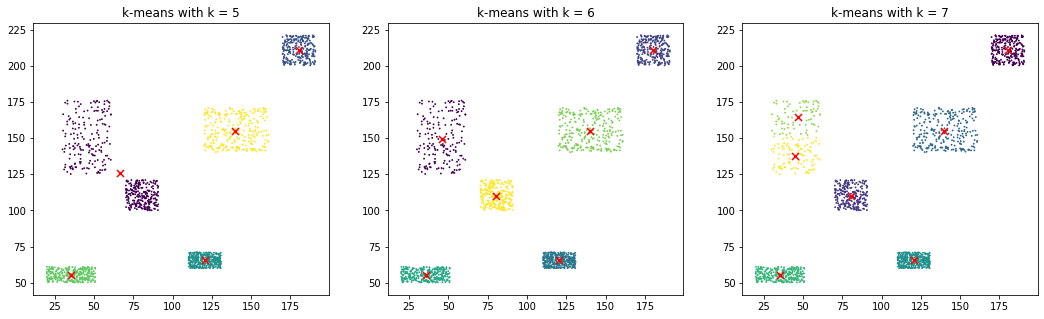

In [30]:
apply_kmeans(dataset_q2b)

(c) Apply the DBSCAN method for clustering the two mentioned columns. Use three different eps and min_samples for clustering.

In [31]:
from sklearn.cluster import DBSCAN

def apply_dbscan(dataset):
    plt.figure(figsize=(18, 15))

    test_arguments = [ (e, ms) for e in [5,10,30] for ms in [5,10,30] ]

    for i in range(len(test_arguments)):
        (eps, min_samples) = test_arguments[i]

        clustering = DBSCAN(eps, min_samples)
        clustering.fit(dataset)

        labels = clustering.labels_

        plt.subplot(3,3, i+1)
        plt.title("DBSCAN with eps = "+ str(eps) +", min_samples = "+ str(min_samples))
        plt.scatter(dataset["Traffic_Volume"], dataset["Particulate_Matter"], s=0.7, c=labels)

    plt.show()

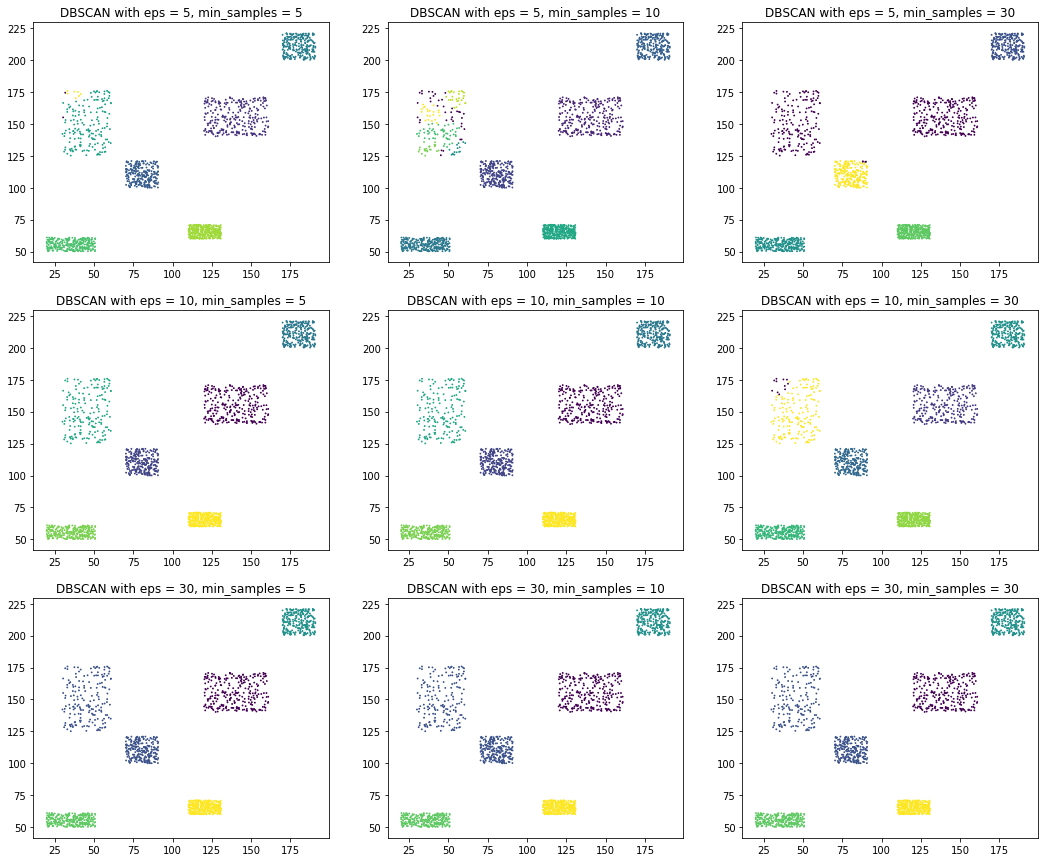

In [32]:
apply_dbscan(dataset_q2b)

(d) Compare k_means and DBSCAN results. Which of these methods is more suitable for clustering this data? Why?

Explanation: 

In general one advantage of DBSCAN is that we don't have to know the number of clusters in advance. In this case the number of clusters can be clearly determined just by looking at the scatter plot. So for `k=6` k-means produces the intuitively expected clustering. 

For small epsilon values (here `eps=5`), DBSCAN seems to get distracted by density fluctuations within the clusters and thus falsely identifies additional clusters. For `eps=30` relatively close clusters merge because the radius of what is interpreted as nearby, became large enough for the algorithm to jump the gap.

Thus, for DBSCAN we have to fiddle more with the input parameters before we get a descent result.

(e) Add noise to the two mentioned columns. For adding noise, first find the range of these two columns and add a random number of 30 samples of noise in the range of each column to that. Plot the scatter diagram again.
Repeat k_means and DBSCAN algorithms for clustering. Which of these methods is more suitable for clustering this data? Why?

In [33]:
import numpy as np

def add_noise(series):
    max_value = series.max()
    min_value = series.min()
    
    noise = (max_value - min_value) * np.random.rand(30) + min_value
    
    return pd.concat([series, pd.Series(noise)])

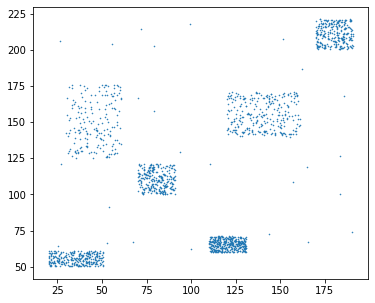

In [34]:
dataset_q2e = pd.DataFrame({
    "Traffic_Volume": add_noise(dataset_q2b["Traffic_Volume"]),
    "Particulate_Matter": add_noise(dataset_q2b["Particulate_Matter"])
})

plt.figure(figsize=(6, 5))
plt.scatter(x=dataset_q2e["Traffic_Volume"], y=dataset_q2e["Particulate_Matter"], s=0.3)
plt.show()

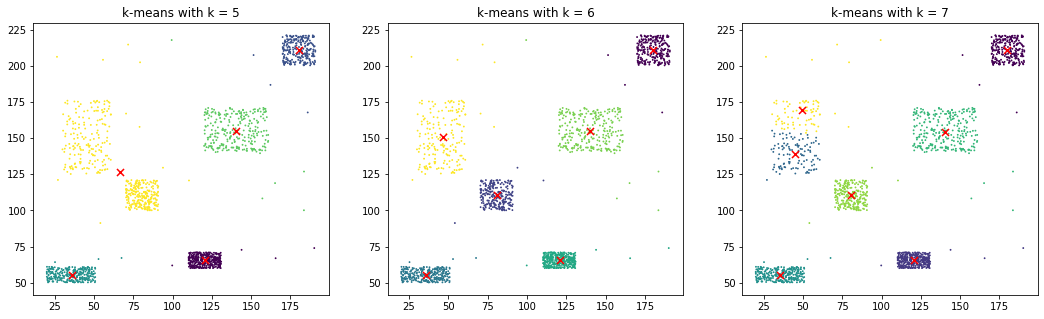

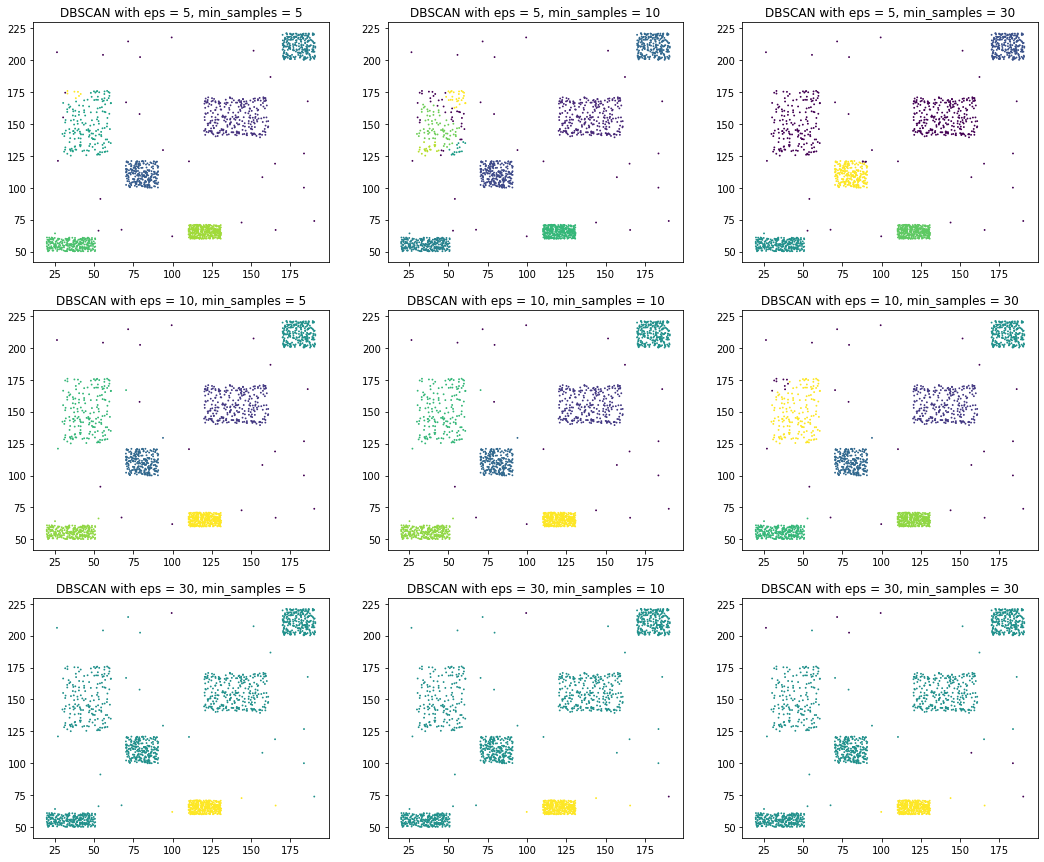

In [35]:
apply_kmeans(dataset_q2e)
apply_dbscan(dataset_q2e)

Explanation:

Still k-means consistently yields the best result when we choose the right number of clusters.

For large epsilon values, DBSCAN now interprets even distant clusters as one, since noise data points between the clusters in some sense build a bridge.

## Question 4 - Frequent itemsets and association rules (15 points): 

(a) You should carry out some preprocessing steps before starting the analysis:
 - Select 90% of 'applications' dataset by random sampling. Use one of the group member's student number as a seed.
 - After completing this preprocessing step, export your final dataset as 'applications_2.csv' dataset and use that for the next steps of the assignment.
 - <font color='red'>Important!</font> Make sure that you submit your extracted dataset with your result in moodle.

In [36]:
import pandas as pd

dataset_q4a = pd.read_csv('applications.csv', header=None)
dataset_q4a = dataset_q4a.sample(frac=0.9, random_state=389343)
dataset_q4a.to_csv('applications_2.csv', header=False)

dataset_q4a

/opt/conda/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3051: DtypeWarning: Columns (86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174) have mixed types. Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


,0,1,2,3,4,5,6,7,8,9,...,165,166,167,168,169,170,171,172,173,174
5342,A_SUBMITTED,A_PARTLYSUBMITTED,A_PREACCEPTED,W_Completeren aanvraag,W_Completeren aanvraag,W_Completeren aanvraag,W_Completeren aanvraag,W_Completeren aanvraag,W_Completeren aanvraag,A_ACCEPTED,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11893,A_SUBMITTED,A_PARTLYSUBMITTED,A_DECLINED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1263,A_SUBMITTED,A_PARTLYSUBMITTED,A_PREACCEPTED,W_Completeren aanvraag,W_Completeren aanvraag,A_ACCEPTED,O_SELECTED,A_FINALIZED,O_CREATED,O_SENT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11645,A_SUBMITTED,A_PARTLYSUBMITTED,W_Afhandelen leads,W_Afhandelen leads,A_PREACCEPTED,W_Completeren aanvraag,W_Afhandelen leads,W_Completeren aanvraag,W_Completeren aanvraag,W_Completeren aanvraag,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1123,A_SUBMITTED,A_PARTLYSUBMITTED,A_PREACCEPTED,W_Completeren aanvraag,W_Completeren aanvraag,W_Completeren aanvraag,W_Completeren aanvraag,W_Completeren aanvraag,W_Completeren aanvraag,W_Completeren aanvraag,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8141,A_SUBMITTED,A_PARTLYSUBMITTED,A_PREACCEPTED,W_Completeren aanvraag,W_Completeren aanvraag,A_DECLINED,W_Completeren aanvraag,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5593,A_SUBMITTED,A_PARTLYSUBMITTED,A_DECLINED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1110,A_SUBMITTED,A_PARTLYSUBMITTED,A_DECLINED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2327,A_SUBMITTED,A_PARTLYSUBMITTED,A_DECLINED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(b) Find the most frequent itemsets with the support of more than 0.4 by using the Apriori algorithm (Hint: When you are creating rows to make the data_set, you should use none_empty strings).

In [37]:
from mlxtend.preprocessing import TransactionEncoder

tr_encoder = TransactionEncoder()

dataset_q4b = dataset_q4a.copy()
dataset_q4b = dataset_q4b.fillna('NaN')
dataset_q4b = dataset_q4b.to_numpy()
dataset_q4b = tr_encoder.fit_transform(dataset_q4b)
dataset_q4b = pd.DataFrame(dataset_q4b, columns=tr_encoder.columns_)
dataset_q4b = dataset_q4b.drop('NaN', axis=1)

dataset_q4b

,A_ACCEPTED,A_ACTIVATED,A_APPROVED,A_CANCELLED,A_DECLINED,A_FINALIZED,A_PARTLYSUBMITTED,A_PREACCEPTED,A_REGISTERED,A_SUBMITTED,...,O_SELECTED,O_SENT,O_SENT_BACK,W_Afhandelen leads,W_Beoordelen fraude,W_Completeren aanvraag,W_Nabellen incomplete dossiers,W_Nabellen offertes,W_Valideren aanvraag,W_Wijzigen contractgegevens
0,True,True,True,False,False,True,True,True,True,True,...,True,True,True,False,False,True,True,True,True,False
1,False,False,False,False,True,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,True,True,True,False,False,True,True,True,True,True,...,True,True,True,False,False,True,False,True,True,False
3,False,False,False,False,True,False,True,True,False,True,...,False,False,False,True,False,True,False,False,False,False
4,True,True,True,False,False,True,True,True,True,True,...,True,True,True,False,False,True,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11773,False,False,False,False,True,False,True,True,False,True,...,False,False,False,False,False,True,False,False,False,False
11774,False,False,False,False,True,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
11775,False,False,False,False,True,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
11776,False,False,False,False,True,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [38]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(dataset_q4b, min_support=0.4, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)
frequent_itemsets['members'] = frequent_itemsets['itemsets'].apply(lambda itemset: len(itemset))
frequent_itemsets

,support,itemsets,members
3,1.000000,(A_SUBMITTED),1
8,1.000000,"(A_SUBMITTED, A_PARTLYSUBMITTED)",2
1,1.000000,(A_PARTLYSUBMITTED),1
0,0.582951,(A_DECLINED),1
5,0.582951,"(A_DECLINED, A_PARTLYSUBMITTED)",2
6,0.582951,"(A_DECLINED, A_SUBMITTED)",2
13,0.582951,"(A_DECLINED, A_SUBMITTED, A_PARTLYSUBMITTED)",3
12,0.562065,"(A_SUBMITTED, W_Completeren aanvraag)",2
17,0.562065,"(A_PREACCEPTED, A_SUBMITTED, W_Completeren aan...",3
16,0.562065,"(A_SUBMITTED, W_Completeren aanvraag, A_PARTLY...",3


(c) Find the most frequent itemsets with the support of more than 0.4 by using the Apriori algorithm having more than 2 members.

In [39]:
frequent_itemsets.loc[frequent_itemsets['members'] > 2]

,support,itemsets,members
13,0.582951,"(A_DECLINED, A_SUBMITTED, A_PARTLYSUBMITTED)",3
17,0.562065,"(A_PREACCEPTED, A_SUBMITTED, W_Completeren aan...",3
16,0.562065,"(A_SUBMITTED, W_Completeren aanvraag, A_PARTLY...",3
15,0.562065,"(A_PREACCEPTED, W_Completeren aanvraag, A_PART...",3
14,0.562065,"(A_PREACCEPTED, A_SUBMITTED, A_PARTLYSUBMITTED)",3
18,0.562065,"(A_PREACCEPTED, A_SUBMITTED, W_Completeren aan...",4


(d) Find the itemsets having min_confidence=0.3 and min_lift=1.2. Print support, confidence and lift of filtered rules in one table.

In [40]:
from mlxtend.frequent_patterns import association_rules

columns = ['antecedents', 'consequents', 'confidence', 'lift', 'support']

rules_association = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.3)
rules_association = rules_association.loc[rules_association['lift'] >= 1.2, columns]

rules_association

,antecedents,consequents,confidence,lift,support
14,"(A_PREACCEPTED, A_SUBMITTED)",(W_Completeren aanvraag),1.0,1.779154,0.562065
16,"(A_SUBMITTED, W_Completeren aanvraag)",(A_PREACCEPTED),1.0,1.779154,0.562065
17,(A_PREACCEPTED),"(A_SUBMITTED, W_Completeren aanvraag)",1.0,1.779154,0.562065
19,(W_Completeren aanvraag),"(A_PREACCEPTED, A_SUBMITTED)",1.0,1.779154,0.562065
27,"(A_PREACCEPTED, A_PARTLYSUBMITTED)",(W_Completeren aanvraag),1.0,1.779154,0.562065
28,"(W_Completeren aanvraag, A_PARTLYSUBMITTED)",(A_PREACCEPTED),1.0,1.779154,0.562065
29,(A_PREACCEPTED),"(W_Completeren aanvraag, A_PARTLYSUBMITTED)",1.0,1.779154,0.562065
30,(W_Completeren aanvraag),"(A_PREACCEPTED, A_PARTLYSUBMITTED)",1.0,1.779154,0.562065
40,(A_PREACCEPTED),(W_Completeren aanvraag),1.0,1.779154,0.562065
41,(W_Completeren aanvraag),(A_PREACCEPTED),1.0,1.779154,0.562065


## Question 5 - Text Mining (15 points)

Among the datasets given for this assignment you will find the files "pg_train" and "pg_test". These two files contain a labeled corpus, already splitted in training and test set.
The corpus consists of sentences from several novels, labeled with the name of the author. The first task is text classification: you will train a set of classifiers that predict the author of a piece of text.

(a) Perform preprocessing on the training corpus (all lowercase, no punctuation, tokenization, stemming, stopword removal) and obtain a binary document-term matrix; train a logistic classifier with the author as target.

In [41]:
import csv
from nltk.stem.snowball import SnowballStemmer

def load_dataset(path):
    dataset = []
    
    # Reading the file on my machine correctly only works with these non-default 
    # encoding parameters. Is this on purpuse?
    with open('pg_train.csv', encoding='ISO-8859-1', newline='\r\n') as file:
        reader = csv.reader(file, delimiter='#')
        for row in reader:
            dataset.append(row)
            
    return pd.DataFrame(dataset, columns=['author', 'sentence'])

def stem_sentence(sentence):   
    stemmer = SnowballStemmer('english')

    word_list = sentence.split(' ')
    word_list = map(stemmer.stem, word_list)
    
    return ' '.join(word_list)


dataset_q5_train = load_dataset('pg_train.csv')
dataset_q5_test = load_dataset('pg_test.csv')

dataset_q5_train['sentence_stemmed'] = dataset_q5_train['sentence'].apply(stem_sentence)
dataset_q5_test['sentence_stemmed'] = dataset_q5_test['sentence'].apply(stem_sentence)

dataset_q5_train

,author,sentence,sentence_stemmed
0,austen,[ Emma by Jane Austen 1816 ] VOLUME I CHAPTER ...,[ emma by jane austen 1816 ] volum i chapter i...
1,austen,Sixteen years had Miss Taylor been in Mr . Woo...,sixteen year had miss taylor been in mr . wood...
2,austen,It was Miss Taylor ' s loss which first brough...,it was miss taylor ' s loss which first brough...
3,austen,The want of Miss Taylor would be felt every ho...,the want of miss taylor would be felt everi ho...
4,austen,"He could not meet her in conversation , ration...","he could not meet her in convers , ration or p..."
...,...,...,...
4494,shakespeare,"Mal . I grant him Bloody , Luxurious , Auarici...","mal . i grant him bloodi , luxuri , auarici , ..."
4495,shakespeare,But feare not yet To take vpon you what is you...,but fear not yet to take vpon you what is your...
4496,shakespeare,"All these are portable , With other Graces wei...","all these are portabl , with other grace weigh..."
4497,shakespeare,"O Scotland , Scotland Mal . If such a one be f...","o scotland , scotland mal . if such a one be f..."


In [42]:
dataset_q5_train['author'].describe()

count       4499
unique         3
top       austen
freq        2062
Name: author, dtype: object

In [43]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

def binary_docterm_matrix(dataset):
    binary_vectorizer = CountVectorizer(stop_words='english', binary=True)

    dataset = binary_vectorizer.fit_transform(dataset['sentence_stemmed'])
    dataset = dataset.todense()
    dataset = pd.DataFrame(dataset, columns=binary_vectorizer.get_feature_names())
    
    return dataset

dataset_q5a_train = binary_docterm_matrix(dataset_q5_train)
dataset_q5a_test = binary_docterm_matrix(dataset_q5_test)

classifier_q5a = LogisticRegression()
classifier_q5a.fit(dataset_q5a_train, dataset_q5_train['author'])

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

(b) Perform preprocessing on the training corpus (all lowercase, no punctuation, tokenization, stemming, stopword removal) and obtain a document-term matrix of counts; train a logistic classifier with the author as target.


In [44]:
def count_docterm_matrix(dataset):
    count_vectorizer = CountVectorizer(stop_words='english', binary=False)

    dataset = count_vectorizer.fit_transform(dataset['sentence_stemmed'])
    dataset = dataset.todense()
    dataset = pd.DataFrame(dataset, columns=count_vectorizer.get_feature_names())
    
    return dataset

dataset_q5b_train = count_docterm_matrix(dataset_q5_train)
dataset_q5b_test = count_docterm_matrix(dataset_q5_test)

classifier_q5b = LogisticRegression()
classifier_q5b.fit(dataset_q5b_train, dataset_q5_train['author'])

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

(c) Perform preprocessing on the training corpus (all lowercase, no punctuation, tokenization, stemming, stopword removal) and obtain a tf-idf scores document-term matrix; train a logistic classifier.

In [45]:
from sklearn.feature_extraction.text import TfidfTransformer

def tfidf_docterm_matrix(dataset):
    count_vectorizer = CountVectorizer(stop_words='english', binary=False)
    tfidf_transformer = TfidfTransformer()

    dataset = count_vectorizer.fit_transform(dataset['sentence_stemmed'])
    dataset = tfidf_transformer.fit_transform(dataset)
    dataset = dataset.todense()
    dataset = pd.DataFrame(dataset, columns=count_vectorizer.get_feature_names())
    
    return dataset

dataset_q5c_train = tfidf_docterm_matrix(dataset_q5_train)
dataset_q5c_test = tfidf_docterm_matrix(dataset_q5_test)

classifier_q5c = LogisticRegression()
classifier_q5c.fit(dataset_q5c_train, dataset_q5_train['author'])

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

(d) Perform preprocessing on the training corpus (all lowercase, no punctuation, tokenization, stemming, stopword removal) and obtain a doc2vec embedding in order to reduce the dimension of the document vector to 300; use the doc2vec model you just trained to convert the training set to a set of document vectors; train a logistic classifier with the author as target.


In [46]:
# TODO

(e) Predict the classification with the four models on the test data.

In [53]:
dataset_q5a_pred = classifier_q5a.predict(dataset_q5a_test)
dataset_q5b_pred = classifier_q5b.predict(dataset_q5b_test)
dataset_q5c_pred = classifier_q5c.predict(dataset_q5c_test)
# dataset_q5d_pred = classifier_q5d.predict(dataset_q5d_test)

(f) Obtain confusion matrices for the four different models.


In [48]:
from sklearn.metrics import confusion_matrix

In [49]:
print('=== for binary document-term matrix ===')
confusion_matrix(dataset_q5_test['author'], dataset_q5a_pred)

=== for binary document-term matrix ===


array([[2062,    0,    0],
       [   0, 1541,    0],
       [   0,    0,  896]])

In [50]:
print('=== for document-term matrix of counts ===')
confusion_matrix(dataset_q5_test['author'], dataset_q5b_pred)

=== for document-term matrix of counts ===


array([[2062,    0,    0],
       [   0, 1541,    0],
       [   0,    0,  896]])

In [51]:
print('=== for document-term matrix with tf-idf scores ===')
confusion_matrix(dataset_q5_test['author'], dataset_q5c_pred)

=== for document-term matrix with tf-idf scores ===


array([[2060,    2,    0],
       [   0, 1541,    0],
       [   0,    0,  896]])

In [52]:
# print('=== for doc2vec ===')
# confusion_matrix(dataset_q5_test['author'], dataset_q5d_pred)

(g) Obtain accuracy and f1-score for the four different models.


In [54]:
from sklearn.metrics import accuracy_score, f1_score

def print_metrics(dataset_pred):
    score_accuracy = accuracy_score(dataset_q5_test['author'], dataset_pred)
    score_f1 = f1_score(dataset_q5_test['author'], dataset_pred, average='weighted')
    
    print('Accuracy: ', score_accuracy)
    print('F1 score: ', score_f1)
    print('\n')
    
    return
    
print('=== for binary document-term matrix ===')
print_metrics(dataset_q5a_pred)

print('=== for document-term matrix of counts ===')
print_metrics(dataset_q5b_pred)

print('=== for document-term matrix with tf-idf scores ===')
print_metrics(dataset_q5c_pred)

# print('=== for doc2vec ===')
# print_metrics(dataset_q5d_pred)

=== for binary document-term matrix ===
Accuracy:  1.0
F1 score:  1.0


=== for document-term matrix of counts ===
Accuracy:  1.0
F1 score:  1.0


=== for document-term matrix with tf-idf scores ===
Accuracy:  0.9995554567681707
F1 score:  0.9995554930666976




(h) Briefly comment on the quality of the predictions for the four models.

Explanation:

At least the first three provide nearly flawless accuracy.

(i) For the two authors Austen and Chesterton separately, build a bigram language model. You should use both training and test data to build the model. Do not perform stemming or stopword removal for this task, but do use the other preprocessing steps described in (a). Use both right and left padding, and manage unknown terms by using a dedicated token.

In [ ]:
# TODO

(j) For each author, use the correspondent language models from (i) to generate, using MLE, a sentence of fifteen words starting from each of the following terms:

In [ ]:
'She'
'They'
'It'

(k) Now, computer another two models (for Austen and Chesterton separately), build a trigram model with the same data as in (i). Use both right and left padding, and manage unknown terms by using a dedicated token.

In [ ]:
# TODO

(l) For each author, use the correspondent language models from (k) to generate, using MLE, a sentence of fifteen words starting from each of the same terms as question (j):

In [ ]:
# TODO

(m) Comment on the quality of the models and generated text. Which model performs better? In general, which differences are there in using trigrams as opposed to bigrams?

Explanation: TODO

## Question 6 - Process Mining (15 points)
For this part, refer to the online docs of pm4py (https://pm4py.fit.fraunhofer.de/).
Important: if you did not do it in the instruction, you should make sure to have the latest pm4py version: to get it is sufficient to type `pip install pm4py --upgrade`.
In this section of the assignment you will be working with a real life event log, derived from the activity of the help desk department of an Italian software company. The data is contained in the file "event_log.xes".

(a) Use the provided event log and identify the least frequent variant and the most frequent variant.


In [96]:
from pm4py.objects.log.importer import xes

dataset_q6a = xes.factory.import_log('event_log.xes')

print('number of traces: ', len(dataset_q6a))

number of traces:  4580


In [97]:
from pm4py.statistics.traces.log import case_statistics

variants_with_count = case_statistics.get_variant_statistics(dataset_q6a)
variants_with_count = sorted(variants_with_count, key=lambda v: v['count'])

#### Most frequent variant:

In [98]:
variants_with_count[-1]

{'variant': 'Assign seriousness,Take in charge ticket,Resolve ticket,Closed',
 'count': 2366}

#### Least frequent variant:

In [99]:
variants_with_count[0]

{'variant': 'Wait,Resolve ticket,Closed', 'count': 1}

(b) Remove all the variants that contain less than 1% of the traces in the log. Create a new event log without these variants.

In [100]:
from pm4py.algo.filtering.log.variants import variants_filter

def is_frequent(variant):
    one_percent = len(dataset_q6a) * 0.01
    return variant['count'] >= one_percent


variants_top99 = filter(is_frequent, variants_with_count)
variants_top99 = map(lambda x: x['variant'], variants_top99)
variants_top99 = list(variants_top99)

dataset_q6b = variants_filter.apply(dataset_q6a, variants_top99)

print('number of traces: ', len(dataset_q6b))

number of traces:  3811


(c) Use Inductive miner algorithm to discover the process model based on you new event log (the filtered log without the infrequent variants of question (b)).


In [101]:
from pm4py.algo.discovery import inductive

net, initial_marking, final_marking = inductive.factory.apply(dataset_q6b)

(d) Perform the token replay conformance checking using your discovered model (c) and the original event log. Does your process model fit the log?


In [102]:
from pm4py.algo.conformance import tokenreplay

# TODO
token_replay_result = tokenreplay.factory.apply(dataset_q6b, net, initial_marking, final_marking)
token_replay_result

[{'trace_is_fit': False,
  'trace_fitness': 0.8,
  'activated_transitions': [Assign seriousness,
   skip_4,
   tauSplit_5,
   Take in charge ticket,
   Resolve ticket,
   skip_10,
   tauJoin_6,
   Closed],
  'reached_marking': ['p_11:1', 'sink:1', 'source:1'],
  'enabled_transitions_in_marking': {Insert ticket, Wait},
  'transitions_with_problems': [Assign seriousness, Resolve ticket],
  'missing_tokens': 2,
  'consumed_tokens': 10,
  'remaining_tokens': 2,
  'produced_tokens': 10},
 {'trace_is_fit': False,
  'trace_fitness': 0.8,
  'activated_transitions': [Assign seriousness,
   skip_4,
   tauSplit_5,
   Take in charge ticket,
   Resolve ticket,
   skip_10,
   tauJoin_6,
   Closed],
  'reached_marking': ['p_11:1', 'sink:1', 'source:1'],
  'enabled_transitions_in_marking': {Insert ticket, Wait},
  'transitions_with_problems': [Assign seriousness, Resolve ticket],
  'missing_tokens': 2,
  'consumed_tokens': 10,
  'remaining_tokens': 2,
  'produced_tokens': 10},
 {'trace_is_fit': False,

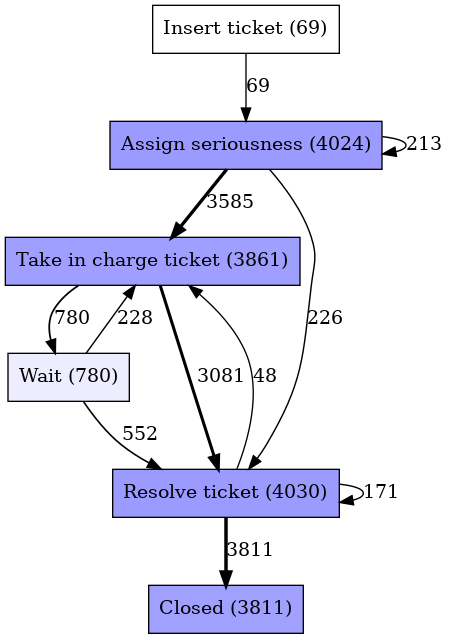

In [106]:
from pm4py.algo.discovery.dfg import factory as dfg_factory

dfg = dfg_factory.apply(dataset_q6b)

from pm4py.visualization.dfg import factory as dfg_vis_factory

gviz_dfg = dfg_vis_factory.apply(dfg, log=dataset_q6b, variant='frequency')

dfg_vis_factory.view(gviz_dfg)

Explanation: TODO

(e) Calculate the fitness of the model in (c).

In [ ]:
# TODO

from pm4py.evaluation import replay_fitness

replay_fitness.factory.apply(dataset_q6a, net, initial_marking, final_marking)

(f) Are there any deviations between the process model and the event log? If so, where and why?

Explanation: TODO

(g) Now use the original event log and remove the two most frequent variants, and discover the model based on your new event log (the filtered log without two most frequent variants).


In [104]:
variants_dropped2 = variants_with_count[:-2]
variants_dropped2 = map(lambda x: x['variant'], variants_dropped2)
variants_dropped2 = list(variants_dropped2)

dataset_q6g = dataset_q6a
dataset_q6g = variants_filter.apply(dataset_q6g, variants_dropped2)

print('number of traces: ', len(dataset_q6g))

number of traces:  1662


In [107]:
net, initial_marking, final_marking = inductive.factory.apply(dataset_q6g)

(h) Perform the token replay conformance checking using the newly discovered model of question (g) and the original event log. Does your process model fit the log?

In [ ]:
# TODO

Explanation: TODO

(i) Calculate the fitness of the model in (g).

In [ ]:
# TODO

(j) Are there any deviations in the process model? If so, where and why?

Explanation: TODO

(k) Use the complete event log (original event log) and discover your process model using Inductive Miner.


In [ ]:
# TODO

(l) Do the token replay conformance checking using your newly discovered model and the original event log. Does your process model fit the log?

In [ ]:
# TODO

Explanation: TODO

(m) How are these three discovered process models different from each other? Which model is the best fitting to the original log? Why?

Explanation: TODO

(n) Visualize the model discovered in question (k) enriched with frequency information. Subsequently, visualize that same model enriched with performance information.

In [ ]:
# TODO

(o) If you were the process owner and you had more resources to hire employees, on which parts of the process would you assign them to maximize efficiency?

Explanation: TODO

(p) Add your further comments and considerations on the frequency and performance informations. Does the process have a "happy path", and is it shown in the enhanced process models? Where are the major bottlenecks in this process? Is there any rework?

Explanation: TODO